In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Hospital Emergency Room Data.csv")

In [8]:
df.head()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patient Admission Flag.1
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,False
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,True
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,True
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,True
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,Male,5,African American,Orthopedics,False,NaN,10,False


In [10]:
df.tail()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patient Admission Flag.1
9211,313-21-4953,28-08-2024 17:38,J,Spradbrow,Male,42,Asian,General Practice,True,NaN,43,True
9212,226-92-3412,28-06-2024 23:12,G,Antoniak,Male,19,Asian,NaN,True,NaN,49,True
9213,412-85-3832,16-05-2024 17:06,V,Riccardo,Male,14,Asian,NaN,True,NaN,36,True
9214,708-91-2439,14-05-2024 23:43,S,Renals,Male,73,Declined to Identify,General Practice,True,1.0,38,True
9215,249-47-9666,01-03-2024 08:50,Y,Greep,Male,35,White,General Practice,True,NaN,39,True


In [12]:
df.shape

(9216, 12)

In [14]:
df.columns

Index(['Patient Id', 'Patient Admission Date', 'Patient First Inital',
       'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime',
       'Patient Admission Flag.1'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient First Inital        9216 non-null   object 
 3   Patient Last Name           9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   bool   
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
 11  Patient Admission Flag.1    9216 non-null   bool   
dtypes: bool(2), float64(1), int64(2), object(7)
memory usage: 738.1+ KB


In [18]:
df.describe()

,Patient Age,Patient Satisfaction Score,Patient Waittime
count,9216.000000,2517.000000,9216.000000
mean,39.855143,4.992054,35.259874
std,22.755125,3.138043,14.735323
min,1.000000,0.000000,10.000000
25%,20.000000,2.000000,23.000000
50%,39.000000,5.000000,35.000000
75%,60.000000,8.000000,48.000000
max,79.000000,10.000000,60.000000


In [20]:
df.isnull().sum()

Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Patient Admission Flag.1         0
dtype: int64

In [22]:
df.duplicated().sum()

0

In [24]:
df = df.drop_duplicates()

In [26]:
df = df.drop(columns=['Patient Admission Flag.1'])

In [32]:
df['Patient Admission Date'] = pd.to_datetime(
    df['Patient Admission Date'],
    format='%d-%m-%Y %H:%M'
)

In [34]:
df['Patient Admission Date'] = pd.to_datetime(df['Patient Admission Date'])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Patient Id                  9216 non-null   object        
 1   Patient Admission Date      9216 non-null   datetime64[ns]
 2   Patient First Inital        9216 non-null   object        
 3   Patient Last Name           9216 non-null   object        
 4   Patient Gender              9216 non-null   object        
 5   Patient Age                 9216 non-null   int64         
 6   Patient Race                9216 non-null   object        
 7   Department Referral         3816 non-null   object        
 8   Patient Admission Flag      9216 non-null   bool          
 9   Patient Satisfaction Score  2517 non-null   float64       
 10  Patient Waittime            9216 non-null   int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2), obj

In [38]:
df['Year'] = df['Patient Admission Date'].dt.year

In [40]:
df['Month'] = df['Patient Admission Date'].dt.month_name()

In [42]:
df['Day'] = df['Patient Admission Date'].dt.day_name()

In [44]:
def age_group(age):
    if age <= 18:
        return "Children"
    elif age <= 35:
        return "Young Adults"
    elif age <= 60:
        return "Adults"
    else:
        return "Senior Citizens"

df['Age Group'] = df['Patient Age'].apply(age_group)

In [46]:
df.to_csv("Cleaned_Hospital_Data.csv", index=False)

In [48]:
print("Total Patients:", len(df))

Total Patients: 9216


In [50]:
print(df['Patient Gender'].value_counts())

Patient Gender
M         4700
F         4470
Male        29
Female      17
Name: count, dtype: int64


In [52]:
print(df['Age Group'].value_counts())

Age Group
Adults             2923
Senior Citizens    2198
Children           2110
Young Adults       1985
Name: count, dtype: int64


In [54]:
print(df['Patient Race'].value_counts())

Patient Race
White                            2571
African American                 1951
Two or More Races                1557
Asian                            1060
Declined to Identify             1030
Pacific Islander                  549
Native American/Alaska Native     498
Name: count, dtype: int64


In [56]:
print(df['Department Referral'].value_counts())

Department Referral
General Practice    1840
Orthopedics          995
Physiotherapy        276
Cardiology           248
Neurology            193
Gastroenterology     178
Renal                 86
Name: count, dtype: int64


In [58]:
print(df['Patient Waittime'].mean())

35.25987413194444


In [60]:
print(df['Patient Satisfaction Score'].mean())

4.992054032578467


In [62]:
print(df['Patient Admission Flag'].value_counts())

Patient Admission Flag
True     4612
False    4604
Name: count, dtype: int64


In [64]:
print(df['Month'].value_counts())

Month
August       1024
May           999
June          991
October       964
July          952
April         948
September     935
January       513
March         506
December      489
November      464
February      431
Name: count, dtype: int64


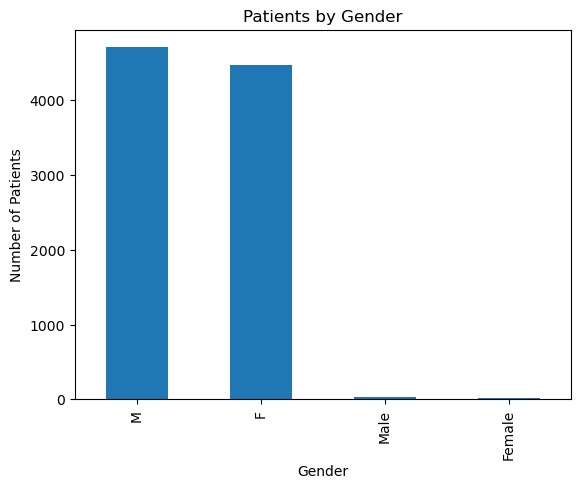

In [66]:
df['Patient Gender'].value_counts().plot(kind='bar')
plt.title("Patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

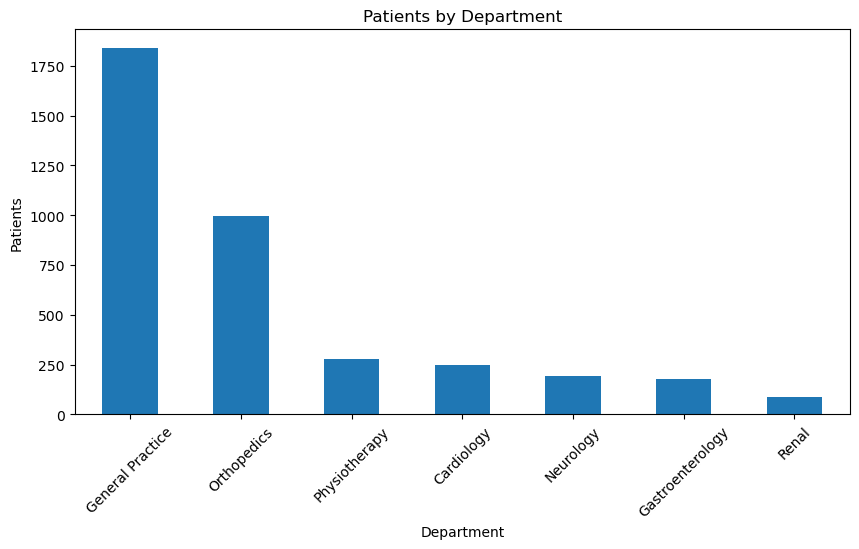

In [68]:
df['Department Referral'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Patients by Department")
plt.xlabel("Department")
plt.ylabel("Patients")
plt.xticks(rotation=45)
plt.show()

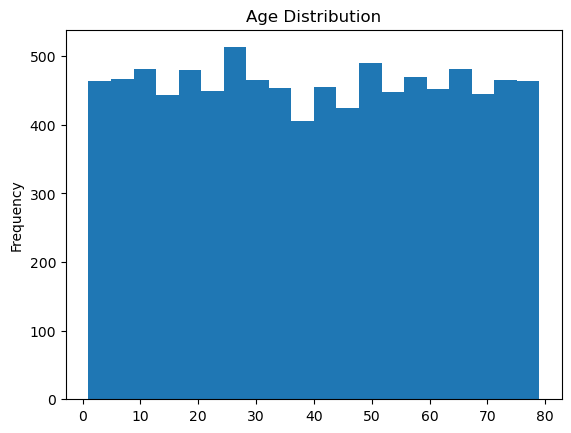

In [70]:
df['Patient Age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")
plt.show()

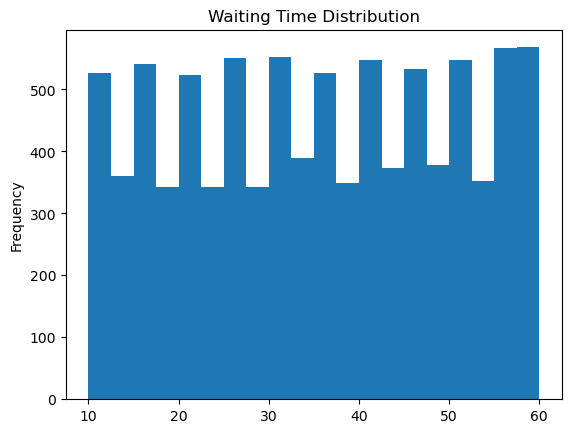

In [72]:
df['Patient Waittime'].plot(kind='hist', bins=20)
plt.title("Waiting Time Distribution")
plt.show()